# Dataset preparation

Automated dataset download (downloads the latest csv file)fetches

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'

data = pd.read_csv(url)

data.head()


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [2]:
# Check for missing values in Province/State
print("Missing values in Province/State before replacement:")
print(data['Province/State'].isnull().sum())

# Replace missing values in Province/State with 'unknown'
data['Province/State'] = data['Province/State'].fillna('unknown')

# Verify replacement
print("\nMissing values in Province/State after replacement:")
print(data['Province/State'].isnull().sum())

# Check for missing values in Country/Region
print("\nMissing values in Country/Region before replacement:")
print(data['Country/Region'].isnull().sum())

# Replace missing values in Country/Region with 'unknown'
data['Country/Region'] = data['Country/Region'].fillna('unknown')

# Verify replacement
print("\nMissing values in Country/Region after replacement:")
print(data['Country/Region'].isnull().sum())

# Check for missing values in Lat and Long
print("\nMissing values in Lat and Long before handling:")
print(data[['Lat', 'Long']].isnull().sum())

data['Lat'] = data['Lat'].fillna(0)  # Replace 0 with appropriate default latitude
data['Long'] = data['Long'].fillna(0)  # Replace 0 with appropriate default longitude

# Verify Lat and Long after handling
print("\nMissing values in Lat and Long after handling:")
print(data[['Lat', 'Long']].isnull().sum())


Missing values in Province/State before replacement:
198

Missing values in Province/State after replacement:
0

Missing values in Country/Region before replacement:
0

Missing values in Country/Region after replacement:
0

Missing values in Lat and Long before handling:
Lat     2
Long    2
dtype: int64

Missing values in Lat and Long after handling:
Lat     0
Long    0
dtype: int64


Top 3 infected countries


1.   Sum infection counts for each country
2. Sort the countries by the total infection count in decending order
3. Display the top three countries

In [3]:
# Retrieve 'Province/State', 'Country/Region', and total infections from the last column
data['Total Infections'] = data.iloc[:, -1]  # Last column already has the total infections

# Sort the data in descending order of 'Total Infections'
data_sorted = data.sort_values(by='Total Infections', ascending=False)

# Retrieve the top 3 entries
top_countries = data_sorted[['Province/State', 'Country/Region', 'Total Infections']].head(3)

print("Top 3 Locations by Total Infections:")
for index, row in top_countries.iterrows():
    province = row['Province/State'] if pd.notna(row['Province/State']) else "Unknown"
    print(f"{row['Country/Region']} ({province}): {row['Total Infections']:,} infections")

Top 3 Locations by Total Infections:
US (unknown): 103,802,702 infections
India (unknown): 44,690,738 infections
France (unknown): 38,618,509 infections


Import

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Weekly data

In [6]:
print(type(top_countries))


<class 'pandas.core.frame.DataFrame'>


<ipython-input-20-9d6fe4e2a67b>:23: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

<ipython-input-20-9d6fe4e2a67b>:37: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

<ipython-input-20-9d6fe4e2a67b>:46: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



Country: US
R² Score: 0.02
Variance: 643041552310.91
Coefficient: 2158.45
Intercept: 454871.06

Country: India
R² Score: 0.02
Variance: 247741848253.83
Coefficient: -1396.54
Intercept: 387719.42

Country: France
R² Score: 0.09
Variance: 163269587612.01
Coefficient: 2599.01
Intercept: 28671.42



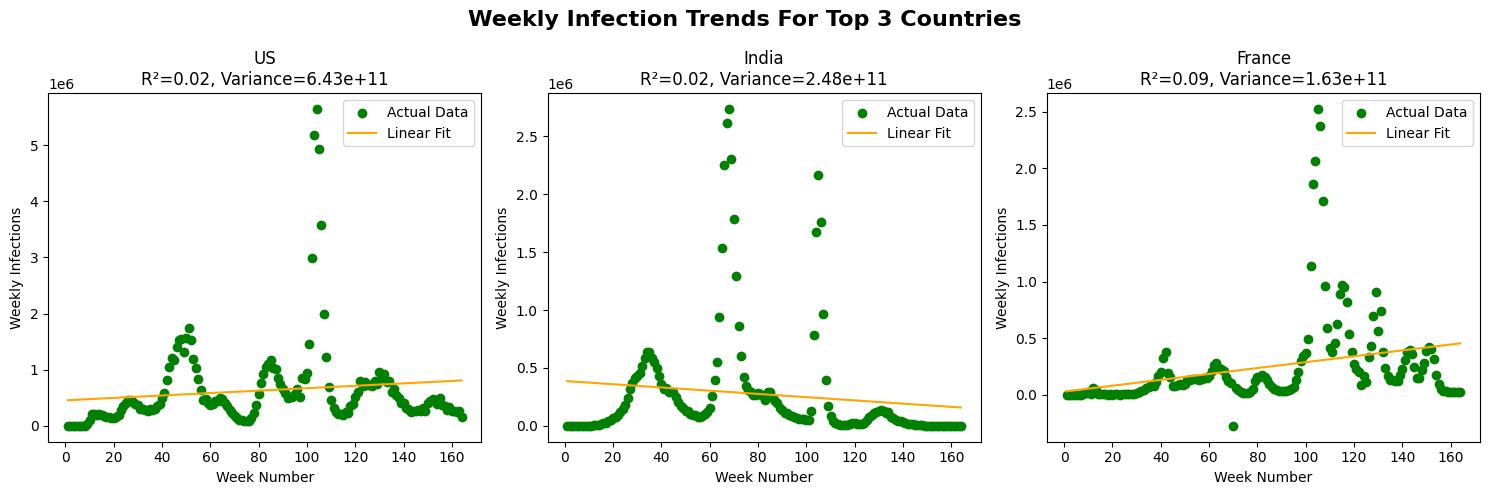

Country with the Highest Variance: US


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

top_countries_list = top_countries['Country/Region'].unique().tolist()

# Columns:
# First four columns are metadata: Province/State, Country/Region, Lat, Long
metadata_cols = ["Province/State", "Country/Region", "Lat", "Long"]
date_columns = data.columns[4:]

# Ensure date columns are numeric
data[date_columns] = data[date_columns].apply(pd.to_numeric, errors='coerce')

# Convert cumulative counts to daily increments
daily_new_cases = data[date_columns].diff(axis=1)

daily_new_cases.iloc[:, 0] = data[date_columns].iloc[:, 0]

# Combine daily increments with metadata
data_daily = pd.concat([data[metadata_cols], daily_new_cases], axis=1)

# Set index to (Province/State, Country/Region) before transposing
data_daily.set_index(["Province/State", "Country/Region"], inplace=True)

# Transpose so rows = dates, columns = (Province/State, Country/Region)
data_transposed = data_daily.T

# Convert the index (which are dates as strings) to actual datetime
data_transposed.index = pd.to_datetime(data_transposed.index, errors='coerce')

# Drop any rows with invalid dates
data_transposed = data_transposed[~data_transposed.index.isna()]

# Sort by date
data_transposed.sort_index(inplace=True)

# Aggregate daily increments to country-level
data_country = data_transposed.groupby(level="Country/Region", axis=1).sum()

# Resample to weekly totals (non-cumulative)
weekly_data = data_country.resample('W').sum()

weekly_data["Week"] = range(1, len(weekly_data) + 1)

r2_scores = {}
variances = {}

plt.figure(figsize=(15, 5))

# Iterate through each top country to fit linear regression
for i, country in enumerate(top_countries_list):
    if country not in weekly_data.columns:
        print(f"{country} not found in dataset. Skipping.")
        continue

    X = weekly_data["Week"].values.reshape(-1, 1)    # Independent variable: Week number
    Y = weekly_data[country].values.reshape(-1, 1)   # Dependent variable: Weekly infections

    # Fit linear regression
    model = LinearRegression()
    model.fit(X, Y)
    Y_pred = model.predict(X)

    # Compute R^2 and variance
    r2 = r2_score(Y, Y_pred)
    variance = np.var(Y, ddof=1)  # sample variance

    # Store results
    r2_scores[country] = r2
    variances[country] = variance

    # Plot the results
    plt.subplot(1, len(top_countries_list), i + 1)
    plt.scatter(X, Y, color='green', label='Actual Data')
    plt.plot(X, Y_pred, color='orange', label='Linear Fit')
    plt.title(f"{country}\nR²={r2:.2f}, Variance={variance:.2e}")
    plt.xlabel("Week Number")
    plt.ylabel("Weekly Infections")
    plt.legend()

    # Print model details
    print(f"Country: {country}")
    print(f"R² Score: {r2:.2f}")
    print(f"Variance: {variance:.2f}")
    print(f"Coefficient: {model.coef_[0][0]:.2f}")
    print(f"Intercept: {model.intercept_[0]:.2f}\n")

plt.suptitle("Weekly Infection Trends For Top 3 Countries", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Country with the highest variance
if variances:
    selected_country = max(variances, key=variances.get)
    print(f"Country with the Highest Variance: {selected_country}")
else:
    print("No countries available to compare variances.")


# Confidence intervals

Comparison Countries: ['US', 'India', 'France']


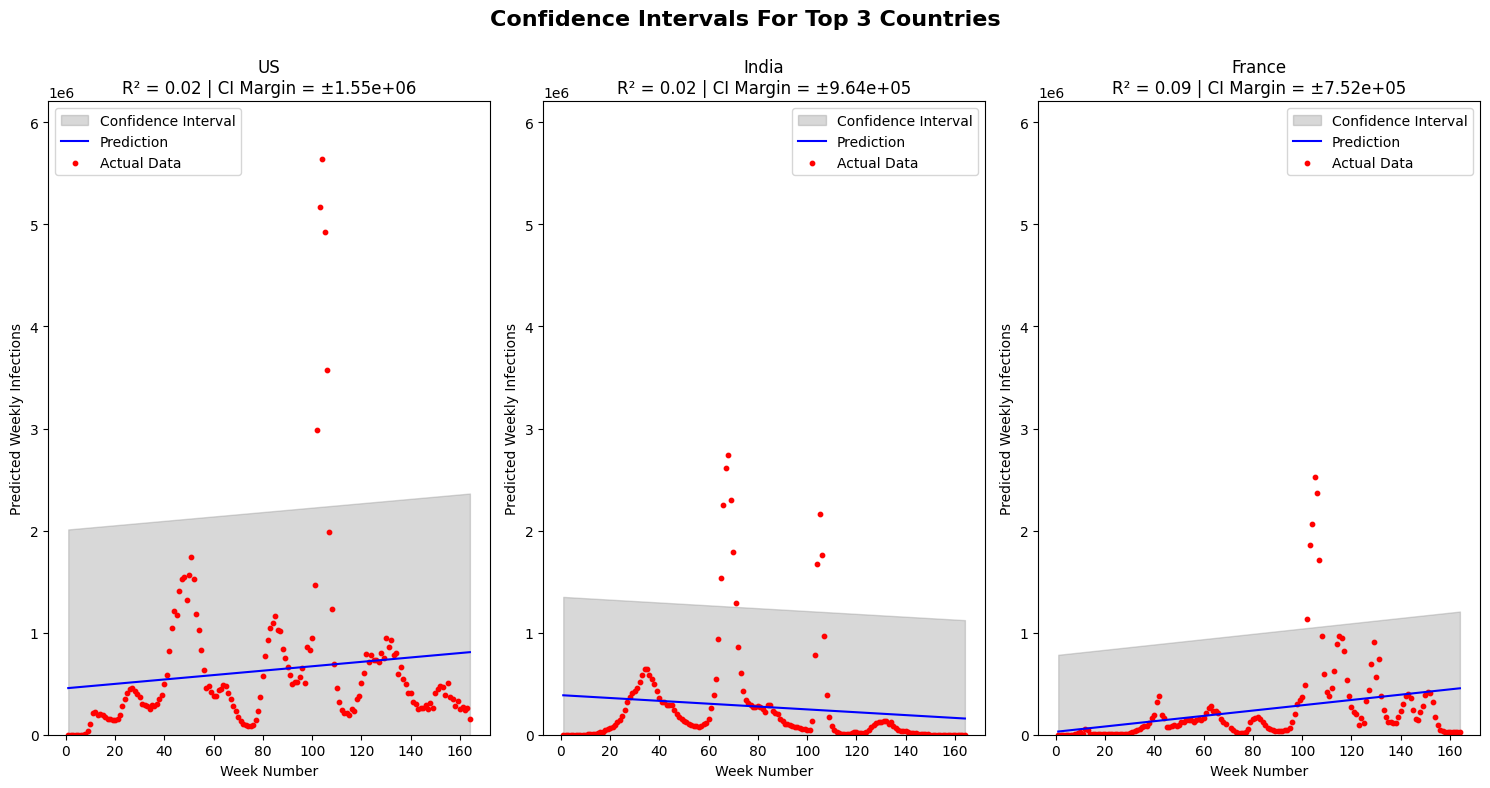

<Figure size 640x480 with 0 Axes>

Confidence Interval Margins:
US: ±1.55e+06 infections
India: ±9.64e+05 infections
France: ±7.52e+05 infections


In [22]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


top_countries_list = top_countries['Country/Region'].unique().tolist()
comparison_countries = top_countries_list


# Function to compute confidence intervals
def compute_confidence_intervals(model, X, Y, Y_pred, alpha=0.05):
    residuals = (Y - Y_pred).flatten()
    variance = np.var(residuals)
    z = norm.ppf(1 - alpha / 2)  # Z-score for the given confidence level
    margin_error = z * np.sqrt(variance)
    return Y_pred - margin_error, Y_pred + margin_error, margin_error

# Initialize a figure for subplots
plt.figure(figsize=(15, 8))
confidence_intervals = {}  # Dictionary to store confidence interval margins

# Find the global Y-axis max for consistent scaling
valid_countries = [c for c in comparison_countries if c in weekly_data.columns]
if not valid_countries:
    raise ValueError("None of the comparison countries are found in weekly_data columns.")

global_y_max = max([weekly_data[c].max() for c in valid_countries])

# Loop through each country in the comparison list
for i, country in enumerate(comparison_countries):
    if country not in weekly_data.columns:
        print(f"Warning: {country} not found in weekly_data columns, skipping.")
        continue

    # Prepare X (week numbers) and Y (weekly infection counts)
    X = weekly_data["Week"].values.reshape(-1, 1)
    Y = weekly_data[country].values.reshape(-1, 1)

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, Y)

    # Predict values
    Y_pred = model.predict(X)

    # Compute confidence intervals
    lower, upper, margin_error = compute_confidence_intervals(model, X, Y, Y_pred)
    confidence_intervals[country] = margin_error

    # Plot predictions and confidence intervals
    plt.subplot(1, len(comparison_countries), i + 1)
    plt.fill_between(X.flatten(), lower.flatten(), upper.flatten(), color='gray', alpha=0.3, label='Confidence Interval')
    plt.plot(X, Y_pred, color='blue', label='Prediction')
    plt.scatter(X, Y, color='red', s=10, label='Actual Data')
    plt.title(f"{country}\nR² = {r2_score(Y, Y_pred):.2f} | CI Margin = ±{margin_error:.2e}")
    plt.xlabel("Week Number")
    plt.ylabel("Predicted Weekly Infections")
    plt.legend()
    plt.ylim(0, global_y_max * 1.1)  # Consistent Y-axis limit

plt.suptitle("Confidence Intervals For Top 3 Countries", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()



# Print confidence interval margins
print("Confidence Interval Margins:")
for country, margin in confidence_intervals.items():
    print(f"{country}: ±{margin:.2e} infections")


# Clustering

## Clustering for the selected country

to validate infection trends for selected country (with highest variance) using K-means clustering in order to identify patterns over time

Performing clustering for: US


<ipython-input-24-b5b8dba8fd84>:21: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



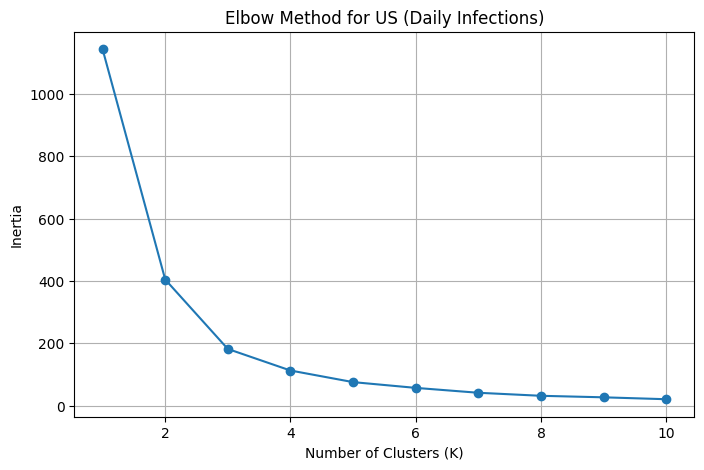


Cluster Summary:
Cluster
4     24991.735986
0     84846.292350
2    193132.989637
3    519504.705882
1    915877.214286
Name: Daily Infections, dtype: float64


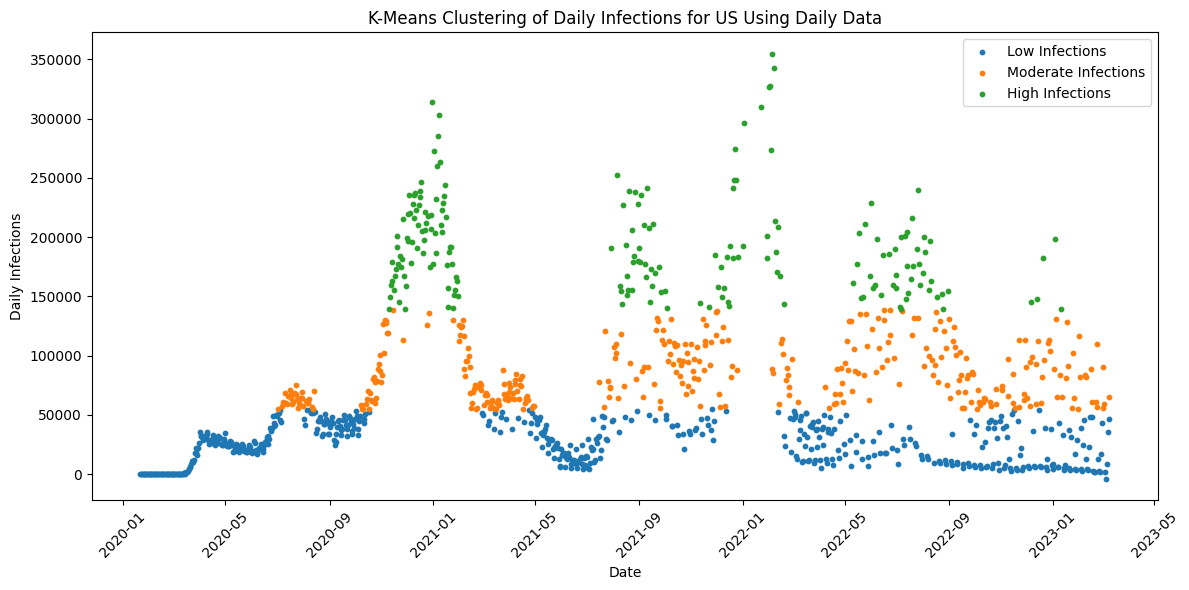

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Focus on the selected country
print(f"Performing clustering for: {selected_country}")

# Extract Daily Infection Data then filter the data for the selected country
country_data = data[data['Country/Region'] == selected_country]

# Extract only the date columns, ignoring metadata like Lat, Long
date_columns = country_data.columns[4:]
daily_infections = country_data[date_columns].sum(axis=0).diff().fillna(0).reset_index()

# Rename columns for clarity
daily_infections.columns = ['Date', 'Daily Infections']

# Convert the "Date" column to datetime format
daily_infections['Date'] = pd.to_datetime(daily_infections['Date'], errors='coerce')
daily_infections.dropna(subset=['Date'], inplace=True)

# Scale the Data for K-Means
scaler = StandardScaler()
scaled_data = scaler.fit_transform(daily_infections[['Daily Infections']])

# Determine the Optimal Number of Clusters using the Elbow Method (1-10)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method to help determine the optimal K
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.title(f'Elbow Method for {selected_country} (Daily Infections)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

# Perform K-Means Clustering
optimal_k = 5 # Adjust based on the elbow method output
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
daily_infections['Cluster'] = kmeans.fit_predict(scaled_data)

# Summarise Clusters and Assign Labels
cluster_summary = daily_infections.groupby('Cluster')['Daily Infections'].mean().sort_values()
cluster_labels = {cluster: label for cluster, label in zip(
    cluster_summary.index, ["Low Infections", "Moderate Infections", "High Infections"]
)}
daily_infections['Cluster Label'] = daily_infections['Cluster'].map(cluster_labels)

print("\nCluster Summary:")
print(cluster_summary)

# Visualise the Clusters
plt.figure(figsize=(12, 6))

for cluster, label in cluster_labels.items():
    cluster_data = daily_infections[daily_infections['Cluster'] == cluster]
    plt.scatter(cluster_data['Date'], cluster_data['Daily Infections'], label=f'{label}', s=10)


# Add Titles and Labels
plt.title(f'K-Means Clustering of Daily Infections for {selected_country} Using Daily Data')
plt.xlabel('Date')
plt.ylabel('Daily Infections')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Clustering with neighbouring countries

In [10]:
from geopy.distance import geodesic

# Ensure the 'selected_country' variable is defined
if "selected_country" not in locals():
    raise ValueError("Please define the 'selected_country' variable before running this code block.")

# Filter data for the selected country and extract coordinates
selected_country_data = data[data["Country/Region"] == selected_country]

if selected_country_data.empty:
    raise ValueError(f"No data found for the selected country: {selected_country}")

# Get latitude and longitude for the selected country
selected_lat = selected_country_data["Lat"].mean()
selected_long = selected_country_data["Long"].mean()
selected_coords = (selected_lat, selected_long)

# Calculate distances to all other countries
def calculate_distance(row):
    country_coords = (row["Lat"], row["Long"])
    return geodesic(selected_coords, country_coords).kilometers

data["Distance"] = data.apply(calculate_distance, axis=1)

# Step 3: Define the distance threshold (in kilometers)
distance_km = 2800  # Adjust this value as needed
neighbouring_data = data[data["Distance"] <= distance_km]
neighbouring_countries = neighbouring_data["Country/Region"].unique().tolist()

if selected_country in neighbouring_countries:
    neighbouring_countries = [c for c in neighbouring_countries if c != selected_country]

comparison_countries = [selected_country] + neighbouring_countries

# Debugging Step: Print results
print(f"Selected Country: {selected_country}")
print(f"Latitude and Longitude: ({selected_lat}, {selected_long})")
print(f"Neighbouring Countries within {distance_km} km: {neighbouring_countries}")


Selected Country: US
Latitude and Longitude: (40.0, -100.0)
Neighbouring Countries within 2800 km: ['Bahamas', 'Belize', 'Canada', 'Mexico']


<ipython-input-10-3ce2fdfa9974>:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["Distance"] = data.apply(calculate_distance, axis=1)


Focusing on Neighbouring Countries: ['US', 'Bahamas', 'Belize', 'Canada', 'Mexico']


<ipython-input-25-2258132f6d06>:37: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

<ipython-input-25-2258132f6d06>:37: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

<ipython-input-25-2258132f6d06>:37: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

<ipython-input-25-2258132f6d06>:37: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

<ipython-input-25-2258132f6d06>:37: UserWarning:

Could not infer format, so each element will be parsed individ

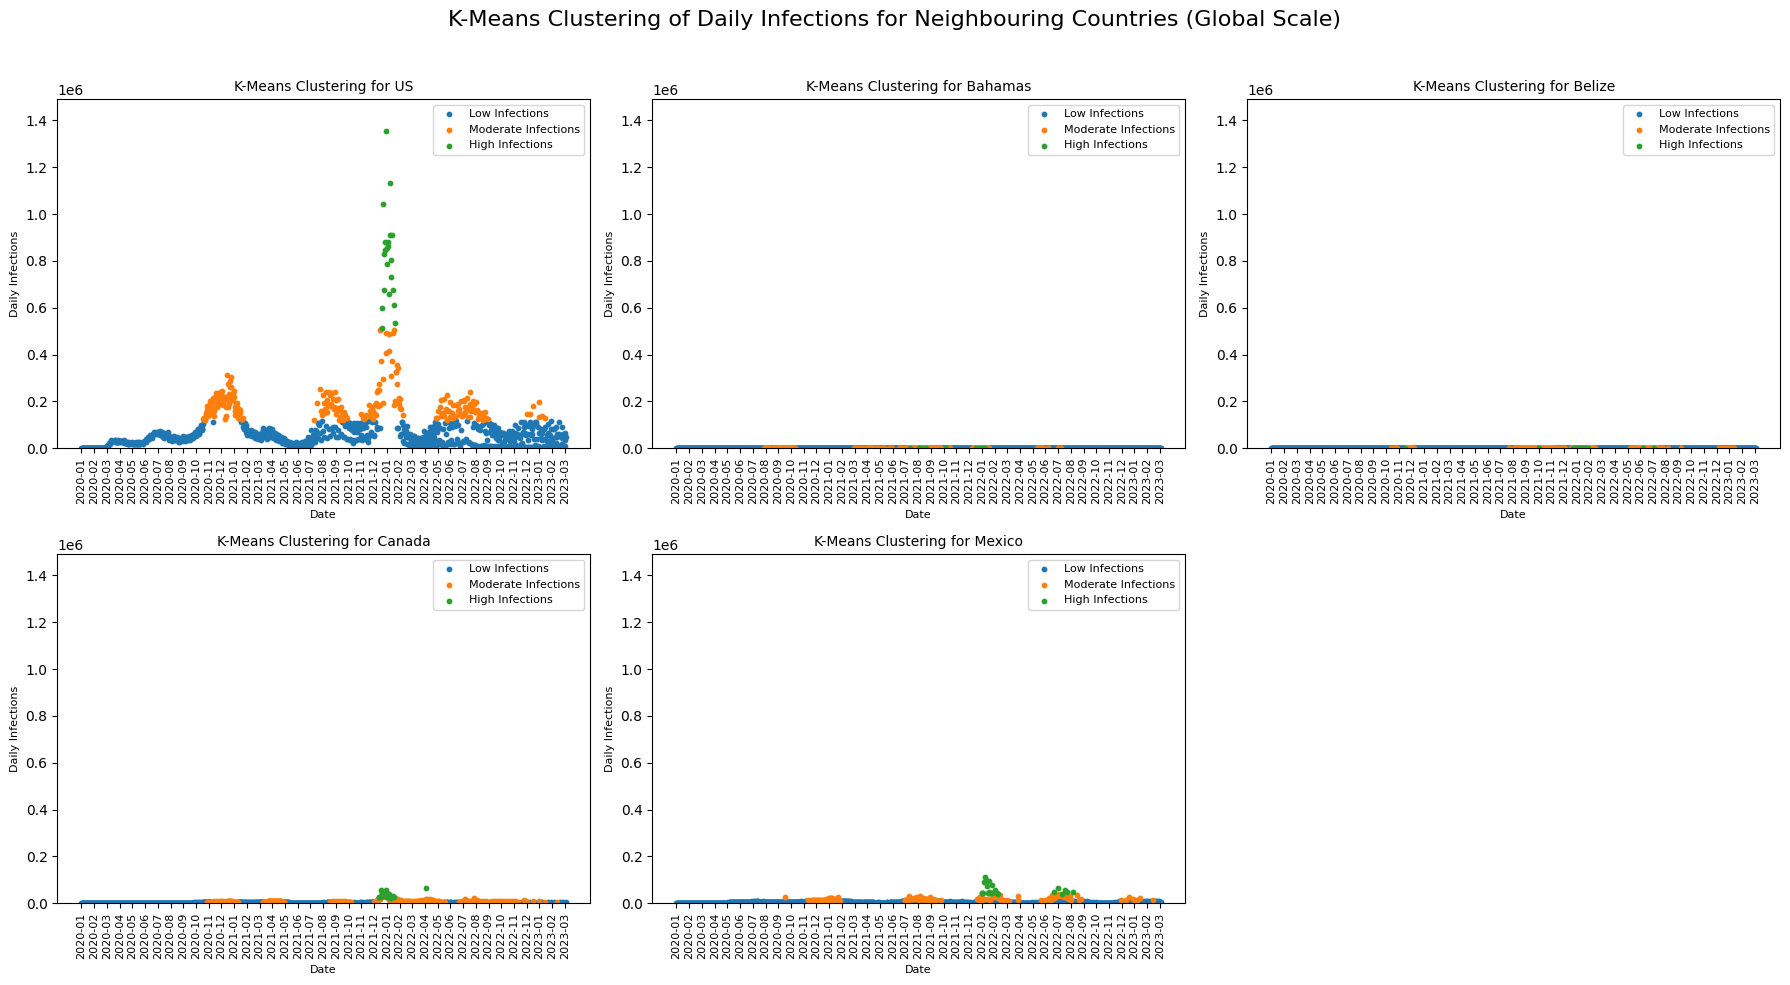

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Focus only on neighbouring countries
comparison_countries = [selected_country] + neighbouring_countries
print(f"Focusing on Neighbouring Countries: {comparison_countries}")

# Step 2: Perform Clustering and Visualize Results
nrows = (len(comparison_countries) + 2) // 3  # Arrange graphs in rows of 3
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
fig.suptitle('K-Means Clustering of Daily Infections for Neighbouring Countries (Global Scale)', fontsize=16)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Find the date columns dynamically
date_columns = data.columns[4:]

# Determine the global Y-axis scale
global_y_max = 0
for country in comparison_countries:
    country_data = data[data['Country/Region'] == country]
    daily_infections = country_data[date_columns].sum(axis=0).diff().fillna(0)
    global_y_max = max(global_y_max, daily_infections.max())

# Perform clustering and plotting for each neighbouring country
for i, country in enumerate(comparison_countries):
    # Extract daily infection data
    country_data = data[data['Country/Region'] == country]
    country_data = country_data[date_columns].sum(axis=0).diff().fillna(0).reset_index()
    country_data.columns = ['Date', 'Daily Infections']
    country_data['Date'] = pd.to_datetime(country_data['Date'], errors='coerce')
    country_data.dropna(subset=['Date'], inplace=True)  # Remove invalid dates

    # Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(country_data[['Daily Infections']])

    # Perform K-Means clustering with optimal K = 3
    optimal_k = 3
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    country_data['Cluster'] = kmeans.fit_predict(scaled_data)

    # Summarize clusters for labeling
    cluster_summary = country_data.groupby("Cluster")['Daily Infections'].mean().sort_values()
    cluster_labels = {cluster: label for cluster, label in zip(
        cluster_summary.index, ["Low Infections", "Moderate Infections", "High Infections"]
    )}
    country_data['Cluster Label'] = country_data['Cluster'].map(cluster_labels)

    # Scatter plot for clustering
    ax = axes[i]
    for cluster, label in cluster_labels.items():
        cluster_data = country_data[country_data['Cluster'] == cluster]
        ax.scatter(cluster_data['Date'], cluster_data['Daily Infections'], label=label, s=10)

    # Set consistent Y-axis limits across all graphs
    ax.set_ylim(0, global_y_max * 1.1)  # Global maximum with 10% buffer

    # Improve X-axis readability
    ax.set_xticks(country_data['Date'][::30])
    ax.set_xticklabels(country_data['Date'][::30].dt.strftime('%Y-%m'), rotation=90, fontsize=8)

    ax.set_title(f'K-Means Clustering for {country}', fontsize=10)
    ax.set_xlabel('Date', fontsize=8)
    ax.set_ylabel('Daily Infections', fontsize=8)
    ax.legend(fontsize=8)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout for spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Scaled

Focusing on Neighbouring Countries: ['US', 'Bahamas', 'Belize', 'Canada', 'Mexico']


<ipython-input-12-63b26ac724c2>:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  country_data['Date'] = pd.to_datetime(country_data['Date'], errors='coerce')
<ipython-input-12-63b26ac724c2>:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  country_data['Date'] = pd.to_datetime(country_data['Date'], errors='coerce')
<ipython-input-12-63b26ac724c2>:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  country_data['Date'] = pd.to_datetime(country_data['Date'], errors='coerce')
<ipython-input-12-63b26ac724c2>:30: UserWarning: Could not infer format, so each element will be parsed

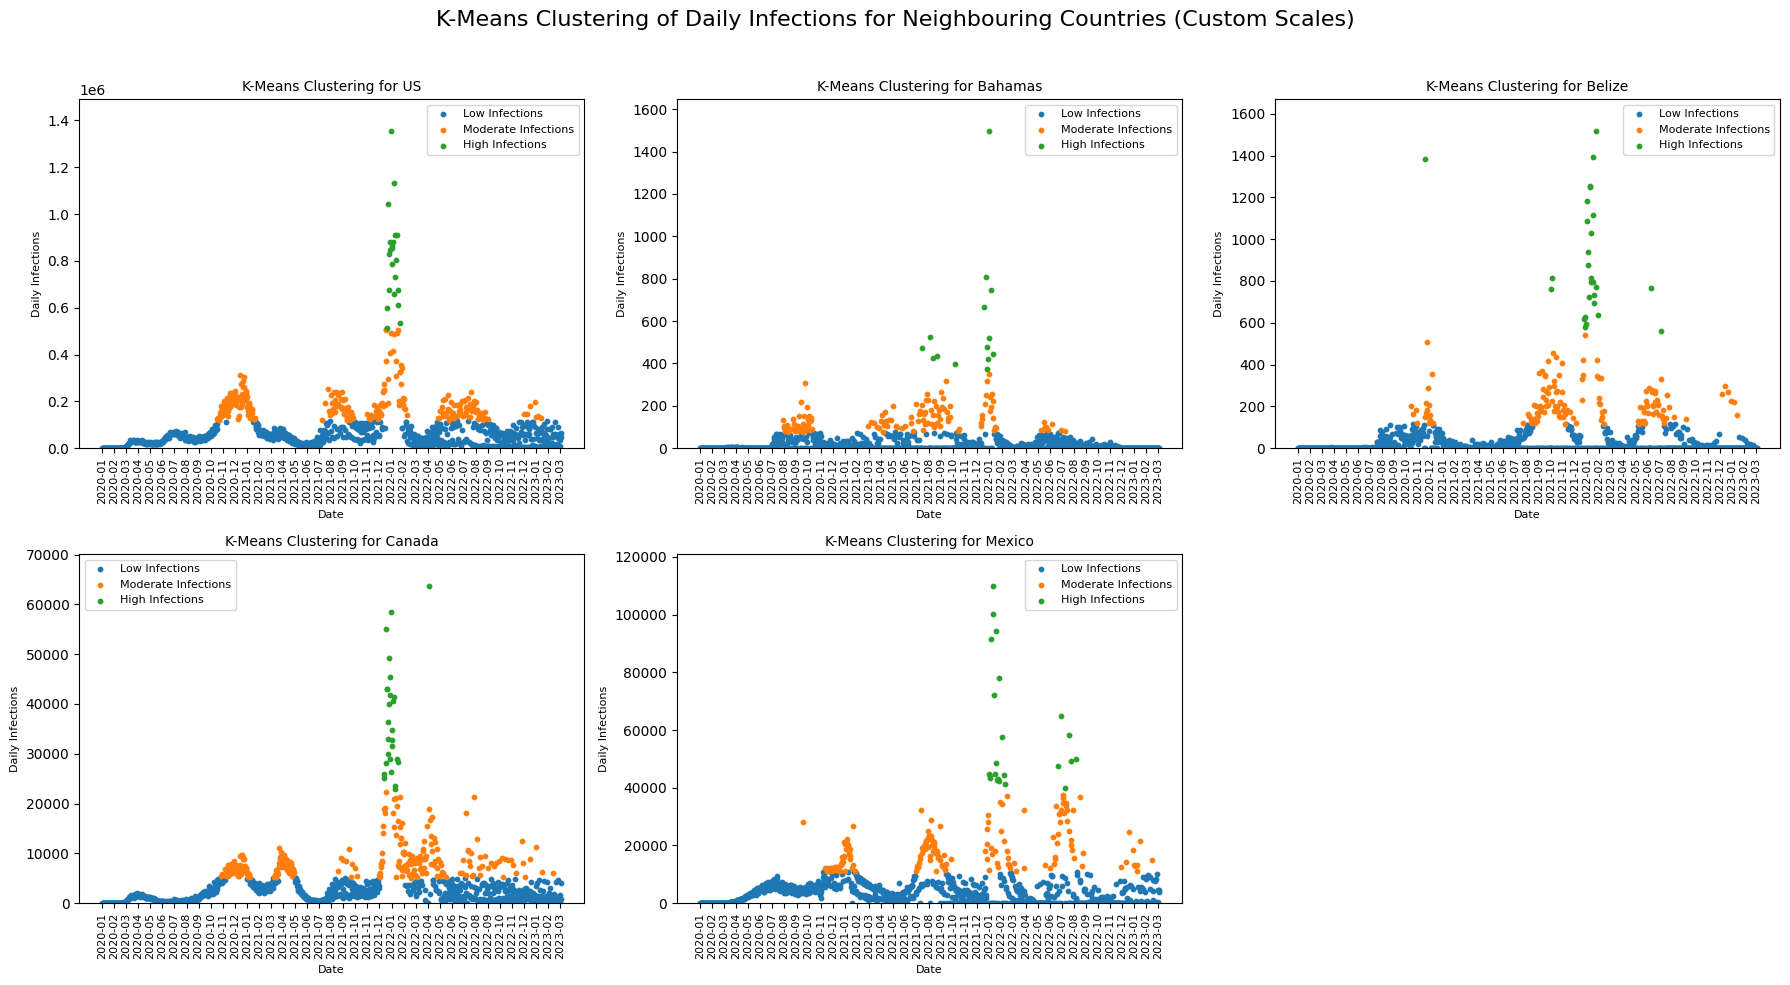

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Focus only on neighbouring countries
comparison_countries = [selected_country] + neighbouring_countries
print(f"Focusing on Neighbouring Countries: {comparison_countries}")

# Perform Clustering and Visualize Results
nrows = (len(comparison_countries) + 2) // 3  # Arrange graphs in rows of 3
ncols = 3

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
fig.suptitle('K-Means Clustering of Daily Infections for Neighbouring Countries (Custom Scales)', fontsize=16)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Find the date columns dynamically
date_columns = data.columns[4:]

# Perform clustering and plotting for each neighbouring country
for i, country in enumerate(comparison_countries):
    # Extract daily infection data
    country_data = data[data['Country/Region'] == country]
    country_data = country_data[date_columns].sum(axis=0).diff().fillna(0).reset_index()
    country_data.columns = ['Date', 'Daily Infections']
    country_data['Date'] = pd.to_datetime(country_data['Date'], errors='coerce')
    country_data.dropna(subset=['Date'], inplace=True)  # Remove invalid dates

    # Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(country_data[['Daily Infections']])

    # Perform K-Means clustering with optimal K = 3
    optimal_k = 3
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    country_data['Cluster'] = kmeans.fit_predict(scaled_data)

    # Summarize clusters for labeling
    cluster_summary = country_data.groupby("Cluster")['Daily Infections'].mean().sort_values()
    cluster_labels = {cluster: label for cluster, label in zip(
        cluster_summary.index, ["Low Infections", "Moderate Infections", "High Infections"]
    )}
    country_data['Cluster Label'] = country_data['Cluster'].map(cluster_labels)

    # Find max infections for dynamic scaling
    y_max = country_data['Daily Infections'].max()

    # Scatter plot for clustering
    ax = axes[i]
    for cluster, label in cluster_labels.items():
        cluster_data = country_data[country_data['Cluster'] == cluster]
        ax.scatter(cluster_data['Date'], cluster_data['Daily Infections'], label=label, s=10)

    # Set dynamic Y-axis limits
    ax.set_ylim(0, y_max * 1.1)

    # Improve X-axis readability
    ax.set_xticks(country_data['Date'][::30])
    ax.set_xticklabels(country_data['Date'][::30].dt.strftime('%Y-%m'), rotation=90, fontsize=8)

    ax.set_title(f'K-Means Clustering for {country}', fontsize=10)
    ax.set_xlabel('Date', fontsize=8)
    ax.set_ylabel('Daily Infections', fontsize=8)
    ax.legend(fontsize=8)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout for spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Linear regression with neighbouring countries

Focusing on Neighbouring Countries: ['US', 'Bahamas', 'Belize', 'Canada', 'Mexico']
Country: US
R² Score: 0.02
Variance of Weekly Infections: 639120567235.85
Model Coefficients: 2158.4514303592555
Model Intercept: 454871.06187341025

Country: Bahamas
R² Score: 0.00
Variance of Weekly Infections: 152192.89
Model Coefficients: -0.024212044128249018
Model Intercept: 230.60115217716591

Country: Belize
R² Score: 0.02
Variance of Weekly Infections: 628964.58
Model Coefficients: 2.462466502523363
Model Intercept: 228.29163549304207

Country: Canada
R² Score: 0.03
Variance of Weekly Infections: 1471688705.73
Model Coefficients: 147.0610463455443
Model Intercept: 16020.481969175522

Country: Mexico
R² Score: 0.01
Variance of Weekly Infections: 2582495007.05
Model Coefficients: 128.9304503965285
Model Intercept: 34993.99393984737



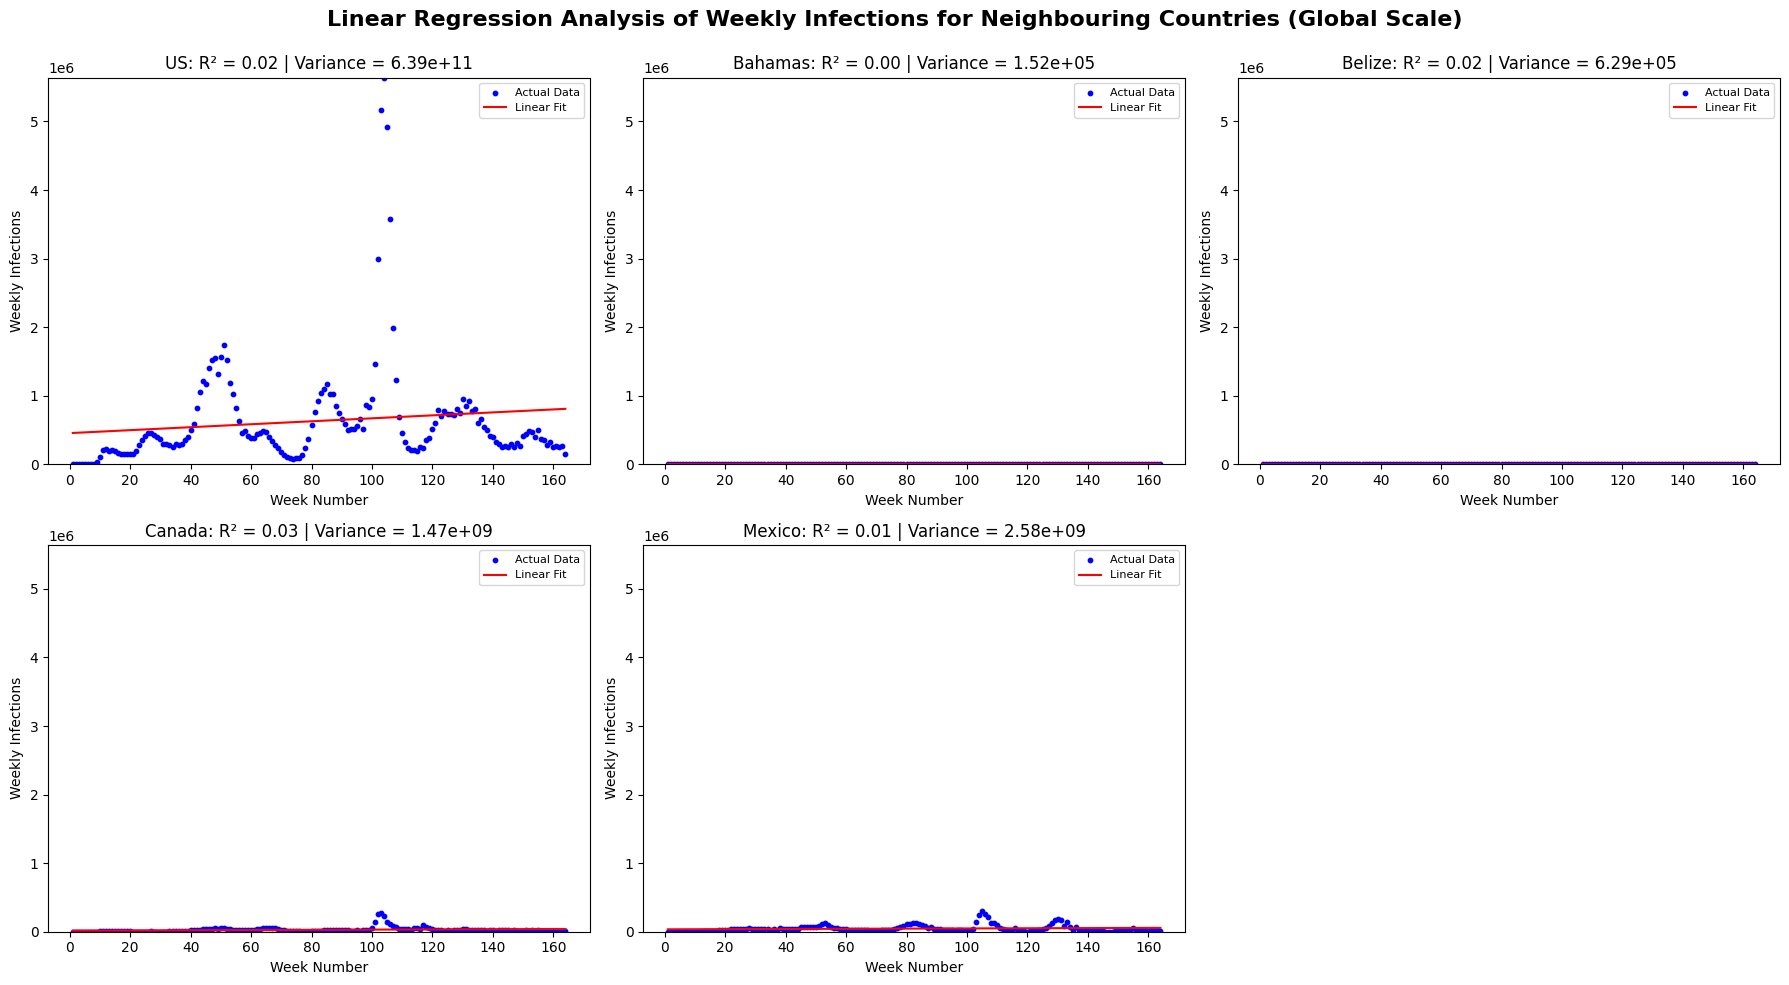

Selected Country with Highest Variance: US


In [13]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# List of neighbouring countries (including the US)
comparison_countries = [selected_country] + neighbouring_countries
print(f"Focusing on Neighbouring Countries: {comparison_countries}")

# Store R^2 scores and variances for each country
r2_scores = {}
variances = {}

# Find the global maximum value of weekly infections for consistent Y-axis scaling
global_max_y = max([weekly_data[country].max() for country in comparison_countries])

nrows = (len(comparison_countries) + 2) // 3
ncols = 3
plt.figure(figsize=(18, 5 * nrows))

for i, country in enumerate(comparison_countries):
    # Prepare X (week numbers) and Y (weekly infection counts)
    X = weekly_data["Week"].values.reshape(-1, 1)
    Y = weekly_data[country].values.reshape(-1, 1)

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, Y)

    # Predict and evaluate R² score
    Y_pred = model.predict(X)
    r2 = r2_score(Y, Y_pred)
    r2_scores[country] = r2

    # Calculate variance of actual weekly infection counts
    variance = np.var(Y)
    variances[country] = variance

    # Plot results
    plt.subplot(nrows, ncols, i + 1)
    plt.scatter(X, Y, color='blue', label='Actual Data', s=10)  # Smaller points
    plt.plot(X, Y_pred, color='red', label='Linear Fit')
    plt.title(f"{country}: R² = {r2:.2f} | Variance = {variance:.2e}")
    plt.xlabel("Week Number")
    plt.ylabel("Weekly Infections")
    plt.ylim(0, global_max_y)  # Consistent Y-axis for all graphs
    plt.legend(fontsize=8)

    # Print results for each country
    print(f"Country: {country}")
    print(f"R² Score: {r2:.2f}")
    print(f"Variance of Weekly Infections: {variance:.2f}")
    print(f"Model Coefficients: {model.coef_[0][0]}")
    print(f"Model Intercept: {model.intercept_[0]}\n")

plt.suptitle("Linear Regression Analysis of Weekly Infections for Neighbouring Countries (Global Scale)",
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Identify the country with the highest variance
selected_country_highest_variance = max(variances, key=variances.get)
print(f"Selected Country with Highest Variance: {selected_country_highest_variance}")


Scaled

Focusing on Neighbouring Countries: ['US', 'Bahamas', 'Belize', 'Canada', 'Mexico']
Country: US
R² Score: 0.02
Variance of Weekly Infections: 639120567235.85
Model Coefficients: 2158.4514303592555
Model Intercept: 454871.06187341025

Country: Bahamas
R² Score: 0.00
Variance of Weekly Infections: 152192.89
Model Coefficients: -0.024212044128249018
Model Intercept: 230.60115217716591

Country: Belize
R² Score: 0.02
Variance of Weekly Infections: 628964.58
Model Coefficients: 2.462466502523363
Model Intercept: 228.29163549304207

Country: Canada
R² Score: 0.03
Variance of Weekly Infections: 1471688705.73
Model Coefficients: 147.0610463455443
Model Intercept: 16020.481969175522

Country: Mexico
R² Score: 0.01
Variance of Weekly Infections: 2582495007.05
Model Coefficients: 128.9304503965285
Model Intercept: 34993.99393984737



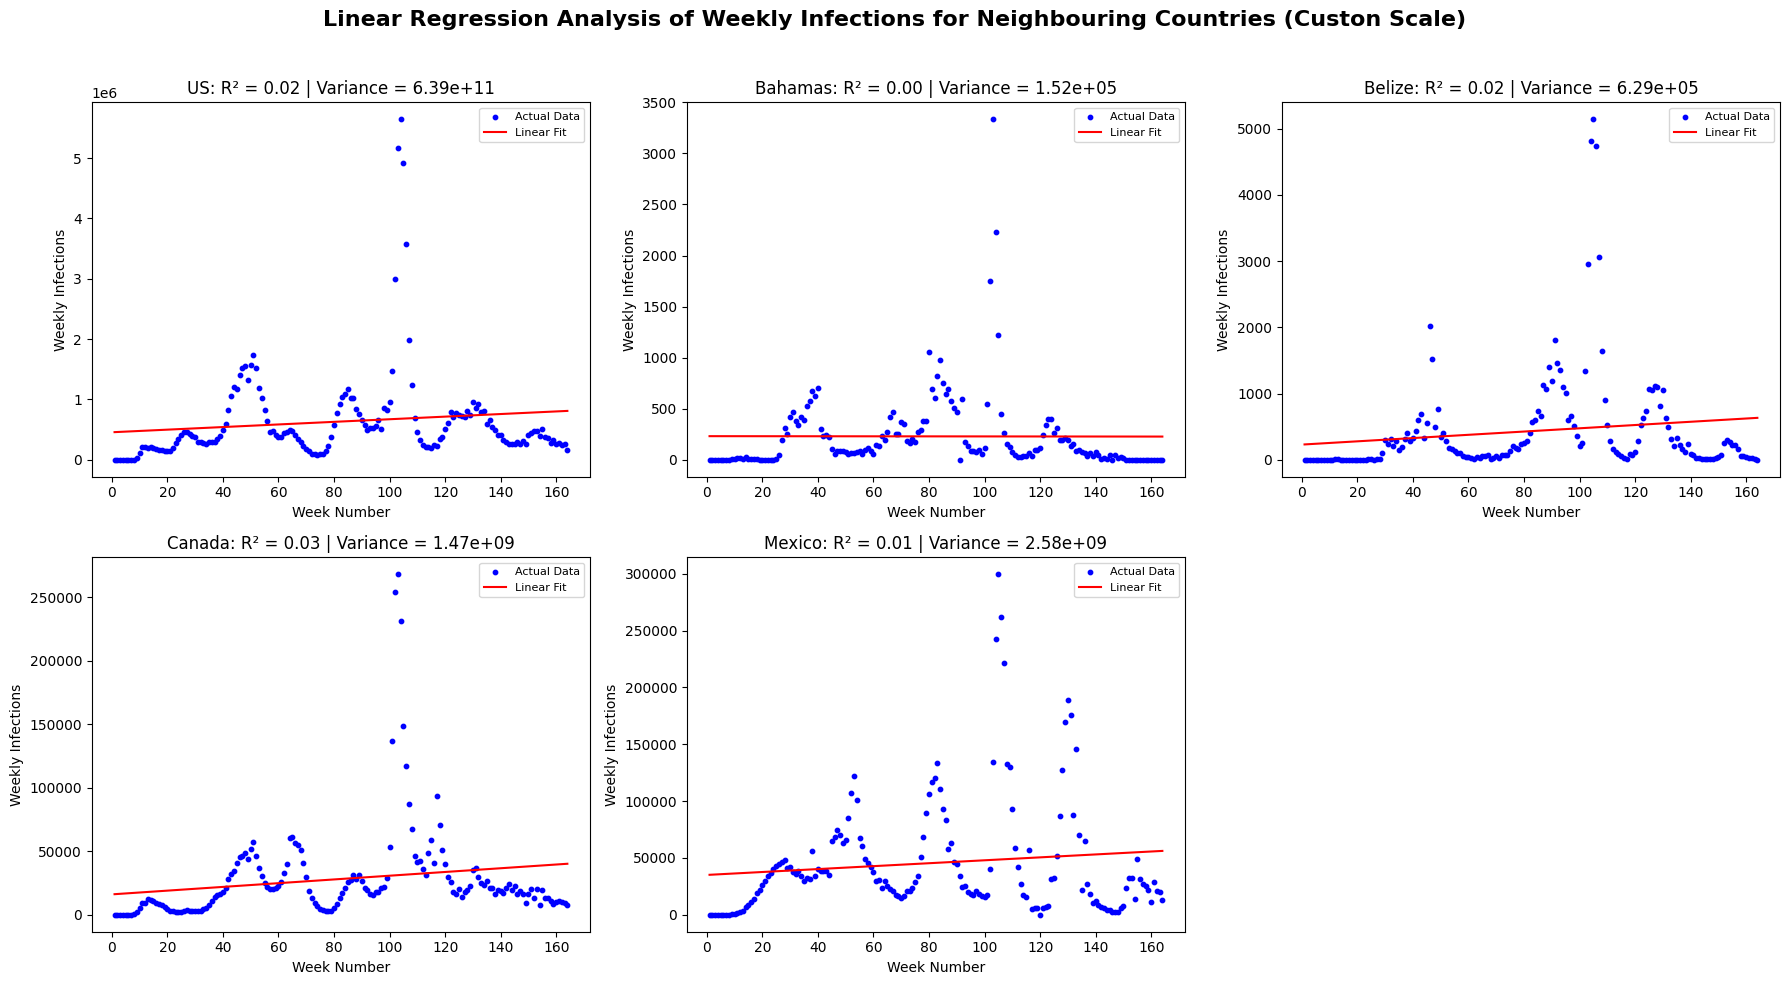

Selected Country with Highest Variance: US


In [14]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# List of neighbouring countries (including the US)
comparison_countries = [selected_country] + neighbouring_countries
print(f"Focusing on Neighbouring Countries: {comparison_countries}")

# Store R^2 scores and variances for each country
r2_scores = {}
variances = {}

nrows = (len(comparison_countries) + 2) // 3
ncols = 3
plt.figure(figsize=(18, 5 * nrows))

for i, country in enumerate(comparison_countries):
    # Prepare X (week numbers) and Y (weekly infection counts)
    X = weekly_data["Week"].values.reshape(-1, 1)
    Y = weekly_data[country].values.reshape(-1, 1)

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, Y)

    # Predict and evaluate R^2 score
    Y_pred = model.predict(X)
    r2 = r2_score(Y, Y_pred)
    r2_scores[country] = r2

    # Calculate variance of actual weekly infection counts
    variance = np.var(Y)
    variances[country] = variance

    # Plot results
    plt.subplot(nrows, ncols, i + 1)
    plt.scatter(X, Y, color='blue', label='Actual Data', s=10)  # Smaller points
    plt.plot(X, Y_pred, color='red', label='Linear Fit')
    plt.title(f"{country}: R² = {r2:.2f} | Variance = {variance:.2e}")
    plt.xlabel("Week Number")
    plt.ylabel("Weekly Infections")
    plt.legend(fontsize=8)

    # Print results for each country
    print(f"Country: {country}")
    print(f"R² Score: {r2:.2f}")
    print(f"Variance of Weekly Infections: {variance:.2f}")
    print(f"Model Coefficients: {model.coef_[0][0]}")
    print(f"Model Intercept: {model.intercept_[0]}\n")

plt.suptitle("Linear Regression Analysis of Weekly Infections for Neighbouring Countries (Custon Scale)",
             fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Identify the country with the highest variance
selected_country_highest_variance = max(variances, key=variances.get)
print(f"Selected Country with Highest Variance: {selected_country_highest_variance}")


# Graph Analytics

## Network Graph

Network graph selected country and neighbours

<ipython-input-15-2d346290529e>:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  neighbouring_data["Node_Label"] = neighbouring_data.apply(


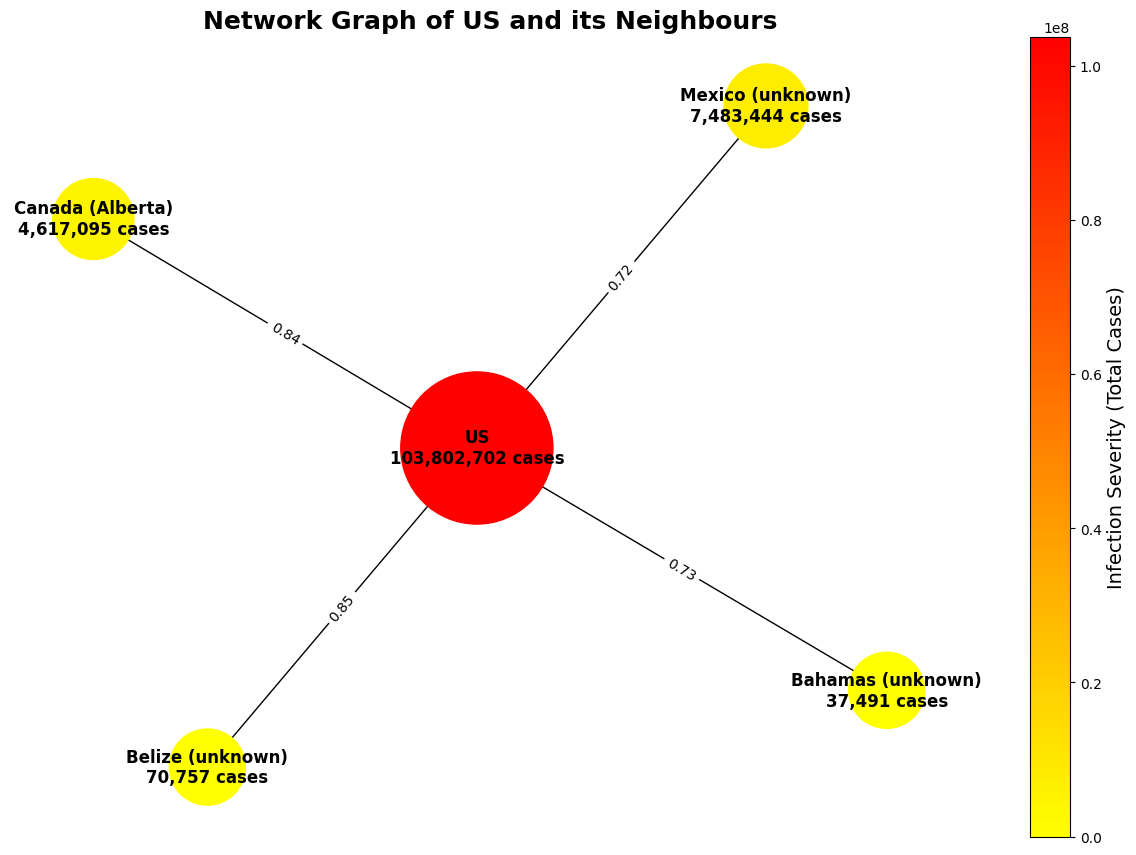


Neighbouring Countries:
['Bahamas', 'Belize', 'Canada', 'Mexico']


In [15]:
import matplotlib.pyplot as plt
import networkx as nx
from geopy.distance import geodesic
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Ensure the latitude and longitude of the selected country are correctly defined
selected_lat = data.loc[data["Country/Region"] == selected_country, "Lat"].mean()
selected_long = data.loc[data["Country/Region"] == selected_country, "Long"].mean()

if pd.isna(selected_lat) or pd.isna(selected_long):
    raise ValueError(f"Coordinates for the selected country ({selected_country}) are missing!")

# Define function to calculate distances
def calculate_distance(row):
    country_coords = (row["Lat"], row["Long"])
    selected_coords = (selected_lat, selected_long)
    return geodesic(selected_coords, country_coords).kilometers

# Add distances to the dataset
data["Distance"] = data.apply(calculate_distance, axis=1)

# Get neighbouring countries within 2800 km
neighbouring_data = data[data["Distance"] <= 2800]
neighbouring_data = neighbouring_data[neighbouring_data["Country/Region"] != selected_country]
neighbouring_countries = list(neighbouring_data["Country/Region"].unique())

# Map node labels
neighbouring_data["Node_Label"] = neighbouring_data.apply(
    lambda row: f"{row['Country/Region']} ({row['Province/State']})", axis=1
)

# Compute correlations
all_countries = [selected_country] + neighbouring_countries
trend_data = weekly_data[all_countries]
correlations = {
    country: trend_data[selected_country].corr(trend_data[country])
    for country in neighbouring_countries
}

# Create a graph
G = nx.Graph()
G.add_node(selected_country, size=trend_data[selected_country].sum())

# Add nodes and edges
for country, corr in correlations.items():
    if not pd.isna(corr):
        label = neighbouring_data.loc[neighbouring_data["Country/Region"] == country, "Node_Label"].values[0]
        node_size = trend_data[country].sum()  # Total cases used for node size
        G.add_node(label, size=node_size)
        G.add_edge(selected_country, label, weight=corr)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# Extract node sizes and colors
node_sizes = [G.nodes[node]["size"] / max(nx.get_node_attributes(G, "size").values()) * 9000 + 3000 for node in G.nodes]
node_colors = [
    plt.cm.autumn_r(G.nodes[node]["size"] / max(nx.get_node_attributes(G, "size").values()))
    for node in G.nodes
]

# Normalize node colors for the colorbar
norm = Normalize(vmin=0, vmax=max(nx.get_node_attributes(G, "size").values()))
sm = ScalarMappable(norm=norm, cmap=plt.cm.autumn_r)
sm.set_array([])

# Custom node labels with total cases
custom_labels = {node: f"{node}\n{int(G.nodes[node]['size']):,} cases" for node in G.nodes}

# Draw graph
nx.draw(
    G,
    pos,
    with_labels=False,
    node_color=node_colors,
    node_size=node_sizes,
)

for node, (x, y) in pos.items():
    label = custom_labels[node]
    plt.text(
        x, y,
        label,
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='center',
        color='black'
    )

# Draw edge weights (to show correlations)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos, edge_labels={k: f"{v:.2f}" for k, v in labels.items()}, font_size=10
)

# Add a colorbar for infection severity
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Infection Severity (Total Cases)", fontsize=14)

plt.title(f"Network Graph of {selected_country} and its Neighbours", fontsize=18, fontweight='bold')
plt.show()

print("\nNeighbouring Countries:")
print(neighbouring_countries)


## Weekly Infection trends

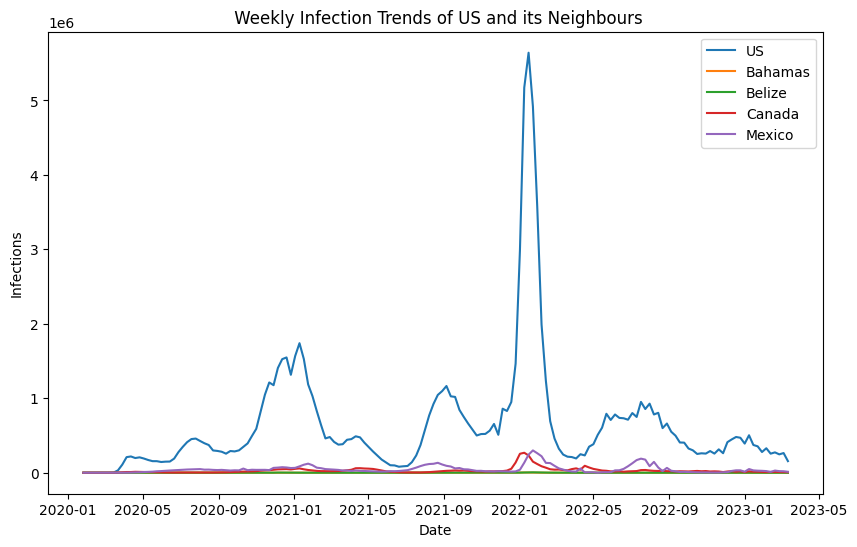

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for country in [selected_country] + neighbouring_countries:
    plt.plot(weekly_data.index, weekly_data[country], label=country)

plt.title(f" Weekly Infection Trends of {selected_country} and its Neighbours")
plt.xlabel("Date")
plt.ylabel("Infections")
plt.legend()
plt.show()


Scaled

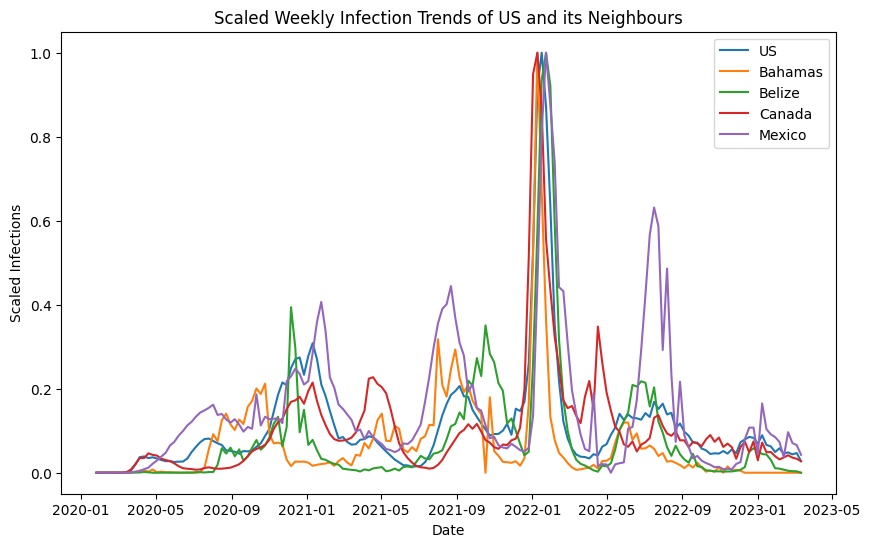

In [17]:
# Scale weekly infection data to normalize the trends
scaled_data = weekly_data.copy()
for country in [selected_country] + neighbouring_countries:
    scaled_data[country] = scaled_data[country] / scaled_data[country].max()

# Plot scaled trends
plt.figure(figsize=(10, 6))
for country in [selected_country] + neighbouring_countries:
    plt.plot(scaled_data.index, scaled_data[country], label=country)

plt.title(f"Scaled Weekly Infection Trends of {selected_country} and its Neighbours")
plt.xlabel("Date")
plt.ylabel("Scaled Infections")
plt.legend()
plt.show()


## Interactive map

In [18]:
!pip install pycountry

In [19]:
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pycountry

# Prepare infection data for selected country and its neighbours
countries_of_interest = [selected_country] + neighbouring_countries
map_data = data[data["Country/Region"].isin(countries_of_interest)]

# Aggregate infections for each country
infection_data = weekly_data[countries_of_interest].sum(axis=0).reset_index()
infection_data.columns = ["Country/Region", "Total Infections"]

# Merge latitude and longitude for plotting
map_data = map_data.groupby(["Country/Region"]).agg({"Lat": "mean", "Long": "mean"}).reset_index()
map_data = map_data.merge(infection_data, on="Country/Region")

# Dynamically map country using pycountry
def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except LookupError:
        print(f"ISO code not found for: {country_name}")
        return None

map_data["ISO"] = map_data["Country/Region"].apply(get_iso3)
map_data = map_data.dropna(subset=["ISO"])  # Drop rows without valid ISO codes

# Print to confirm
print("Map Data with ISO Codes:")
print(map_data)

# Perform clustering (K-Means) on the Total Infection Data
scaler = StandardScaler()
scaled_infections = scaler.fit_transform(map_data[["Total Infections"]])

# Dynamically adjust the number of clusters
n_clusters = min(3, len(map_data))  # At most 3 clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
map_data["Cluster"] = kmeans.fit_predict(scaled_infections)

# Add meaningful cluster labels
cluster_labels = {
    0: "Low Infection Rate",
    1: "Moderate Infection Rate",
    2: "High Infection Rate"
}
map_data["Cluster Label"] = map_data["Cluster"].map(cluster_labels)

# Plot the choropleth map with clusters and borders
fig = px.choropleth(
    map_data,
    locations="ISO",
    color="Cluster Label",  # Use cluster labels
    hover_name="Country/Region",
    hover_data={"Total Infections": True, "Cluster Label": True},
    title="Geographical Clustering of Total Infections",
    color_discrete_map={
        "Low Infection Rate": "lightgreen",
        "Moderate Infection Rate": "orange",
        "High Infection Rate": "red"
    }
)

fig.update_geos(
    showcoastlines=True,
    coastlinecolor="Black",
    showland=True,
    landcolor="White",
    showcountries=True,
    countrycolor="Black"
)

# Map layout
fig.update_layout(
    geo=dict(projection_type="natural earth"),
    title=dict(text="Geographical Clustering of Total Infections", font=dict(size=24)),
    margin=dict(l=0, r=0, t=50, b=0),
    height=800,
    width=1200,
)

# Display the map
fig.show()


Map Data with ISO Codes:
  Country/Region        Lat        Long  Total Infections  ISO
0        Bahamas  25.025885  -78.035889           37491.0  BHS
1         Belize  17.189900  -88.497600           70757.0  BLZ
2         Canada  44.303475  -75.162369         4617095.0  CAN
3         Mexico  23.634500 -102.552800         7483444.0  MEX
4             US  40.000000 -100.000000       103802702.0  USA
